In [1]:
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
from torchvision import datasets, transforms

In [2]:
input_dim = 784 # MNIST 28x28 = 784
hidden_dim = 200 # mid layer dim
latent_dim = 20 # latent variable z's dim
epochs = 30
learning_rate = 3e-4
batch_size = 32

In [30]:
class Encoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim):
        super().__init__()
        self.linear = nn.Linear(input_dim, hidden_dim)
        self.linear_mu = nn.Linear(hidden_dim, latent_dim)
        self.linear_logvar = nn.Linear(hidden_dim, latent_dim)
    
    def forward(self, x):
        h = self.linear(x)
        h = F.relu(h)
        mu = self.linear_mu(h)
        logvar = self.linear_logvar(h) ## logvar as output to cover -inf to +inf
        sigma = torch.exp(0.5 * logvar)
        return mu, sigma

class Decoder(nn.Module):
    def __init__(self, latent_dim, hidden_dim, output_dim):
        super().__init__()
        self.linear1 = nn.Linear(latent_dim, hidden_dim)
        self.linear2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, z):
        h = self.linear1(z)
        h = F.relu(h)
        h = self.linear2(h)
        x_hat = F.sigmoid(h)
        return x_hat

def reparameterize(mu, sigma):
    eps = torch.randn_like(sigma)
    z = mu + eps * sigma
    return z

class VAE(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim):
        super().__init__()
        self.encoder = Encoder(input_dim, hidden_dim, latent_dim)
        self.decoder = Decoder(latent_dim, hidden_dim, input_dim)

    def get_loss(self, x):
        mu, sigma = self.encoder(x)
        z = reparameterize(mu, sigma)
        x_hat = self.decoder(z)
        #print(x.shape, x_hat.shape)
        #print((F.mse_loss(x_hat, x, reduction='none')).shape)
        
        batch_size = len(x)
        L1 = F.mse_loss(x_hat, x, reduction='sum')
        L2 = - torch.sum(1 + torch.log(sigma ** 2) - mu ** 2 - sigma ** 2)
        #print(L1.shape, mu.shape, sigma.shape, L2.shape, batch_size)
        return (L1 + L2) / batch_size


## Downloading Dataset

In [5]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(torch.flatten)
])
dataset = datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)
dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=True
)

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 9912422/9912422 [00:16<00:00, 595646.18it/s] 


Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 28881/28881 [00:00<00:00, 398341.64it/s]


Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 1648877/1648877 [00:00<00:00, 3040395.96it/s]


Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 4542/4542 [00:00<00:00, 2346991.35it/s]

Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw



## Training the model

In [31]:
model = VAE(input_dim, hidden_dim, latent_dim)
optimizer = optim.Adam(model.parameters(), lr= learning_rate)
losses = []

# train
for epoch in range(epochs):
    loss_sum = 0.0
    cnt = 0

    for x, label in dataloader:
        optimizer.zero_grad()
        loss = model.get_loss(x)
        loss.backward()
        optimizer.step()

        loss_sum += loss.item()
        cnt += 1


    loss_avg = loss_sum / cnt
    losses.append(loss_avg)
    print(loss_avg)


53.84035850016276
45.16270030924479
43.32344756266276
42.27146923014323
41.62360542399089
41.06434208170573
40.72112621866862
40.405976729329424
40.2022172668457
40.00444258219401
39.84077649332682
39.70174541625977
39.602446055094404
39.5178093770345
39.391378401692705
39.320285013834635
39.23571593221028
39.14205155334473
39.11620984090169
39.00542275797526
38.957675764973956
38.921643619791666
38.86413227742513
38.801171162923175
38.76229616292318
38.70635821228027
38.67660599568685
38.63022355448405
38.601697224934895
38.56033535563151


## Generate Image

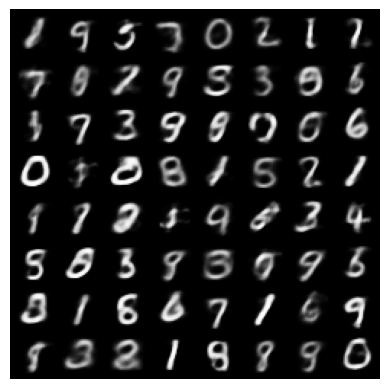

In [32]:
with torch.no_grad():  # disable gradient calculation under with paragraph to save memory
    sample_size = 64
    z = torch.randn(sample_size, latent_dim)  ## generate 64 flattened-image samples from z domain
    x = model.decoder(z)                      ## generate x from z using trained model
    generated_images = x.view(sample_size, 1, 28, 28)   ## convert it to 64 images.

grid_img = torchvision.utils.make_grid(  ## sort generated images into grid for visual representation
    generated_images,
    nrow=8,
    padding=2,
    normalize=True
)

plt.imshow(grid_img.permute(1,2,0))   # 
plt.axis('off')
plt.show()